# Example: Singular Value Decomposition (SVD) of the Daily Growth Rate of the S&P500.
In this example, we decompose the daily growth rate values for components of the S&P500 using SVD.
Singular value decomposition helps us break down complex data into simpler, interpretable components.

> __Learning Objectives:__
>
> By the end of this example, you will be able to:
>
> * __Matrix layout and factorization:__ Arrange a panel of daily growth rates as a matrix whose rows index trading intervals and whose columns index firms. Factor that matrix into a set of orthogonal modes ordered by how much of its variation each mode carries.
> * __Singular values and loadings:__ Read singular values as weights that rank the modes by the share of matrix variation they explain. Read the firm loadings within each mode to separate market-wide co-movement from sector-level structure.
> * __Low-rank reconstruction and co-movement:__ Reconstruct the growth-rate matrix from a truncated set of modes and compare it against the full matrix. Read those reconstructions to see which firms move together and which intervals carry the largest shared movements.


By applying SVD to the daily growth rates of S&P500 stocks, we can uncover underlying patterns and trends in the market. Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # activate the course environment and load shared packages

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We gathered a daily open-high-low-close `dataset` for each firm in the [S&P500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024`, along with data for a few exchange-traded funds and volatility products during that time. 

Let's load the `original_dataset::DataFrame` by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet) and remove firms that do not have the maximum number of trading days. The cleaned dataset $\mathcal{D}$ will be stored in the `dataset` variable.

In [2]:
original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"] # map ticker symbols to historical-price DataFrames

Dict{String, DataFrame} with 515 entries:
  "DD"   => 2329×8 DataFrame…
  "EMR"  => 2767×8 DataFrame…
  "CTAS" => 2767×8 DataFrame…
  "HSIC" => 2767×8 DataFrame…
  "KIM"  => 2767×8 DataFrame…
  "PLD"  => 2767×8 DataFrame…
  "IEX"  => 2767×8 DataFrame…
  "TPR"  => 1803×8 DataFrame…
  "BAC"  => 2767×8 DataFrame…
  "CBOE" => 2767×8 DataFrame…
  "EXR"  => 2767×8 DataFrame…
  "NCLH" => 2767×8 DataFrame…
  "CVS"  => 2767×8 DataFrame…
  "DRI"  => 2767×8 DataFrame…
  "DTE"  => 2767×8 DataFrame…
  "ZION" => 2767×8 DataFrame…
  "AVY"  => 2767×8 DataFrame…
  "EW"   => 2767×8 DataFrame…
  "EA"   => 2767×8 DataFrame…
  "NWSA" => 2767×8 DataFrame…
  "BBWI" => 859×8 DataFrame…
  "CAG"  => 2767×8 DataFrame…
  "GPC"  => 2767×8 DataFrame…
  "FCX"  => 2767×8 DataFrame…
  "GILD" => 2767×8 DataFrame…
  ⋮      => ⋮

Not all tickers in our dataset have the maximum number of trading days for various reasons, e.g., acquisition or de-listing events. Let's collect only those tickers with the maximum number of trading days.

First, let's compute the number of records for a firm that we know has a maximum value, e.g., `AAPL`, and save that value in the `maximum_number_trading_days::Int64` variable:

In [3]:
maximum_number_trading_days = original_dataset["AAPL"] |> nrow # use a full-history ticker to establish the required row count

2767

Now, let's iterate through our data and collect only tickers with `maximum_number_trading_days` records. Save that data in the `dataset::Dict{String,DataFrame}` variable:

In [4]:
dataset = let

    # Initialize -
    dataset = Dict{String, DataFrame}(); # cleaned mapping from ticker symbols to complete price histories

    # Retain firms with complete histories; dictionary traversal order is not guaranteed -
    for (ticker, data) ∈ original_dataset # unpack one ticker-history pair
        if (nrow(data) == maximum_number_trading_days) # exclude shorter histories caused by listings or delistings
            dataset[ticker] = data; # preserve the complete DataFrame under its ticker symbol
        end
    end
    dataset; # return the cleaned dictionary from the let block
end;

How many firms do we have the full number of trading days? Let's use [the `length(...)` function](https://docs.julialang.org/en/v1/base/collections/#Base.length) - notice this works for dictionaries, in addition to arrays, sets and other collections.

In [5]:
length(dataset) # display the number of retained firms

424

Finally, let's get a list of the firms in our cleaned up dataset (and sort them alphabetically). We store the sorted firm ticker symbols in the `list_of_tickers::Array{String,1}` variable.

In [6]:
list_of_tickers = keys(dataset) |> collect |> sort # alphabetized ticker order used to align matrix columns

424-element Vector{String}:
 "A"
 "AAL"
 "AAP"
 "AAPL"
 "ABBV"
 "ABT"
 "ACN"
 "ADBE"
 "ADI"
 "ADM"
 "ADP"
 "ADSK"
 "AEE"
 ⋮
 "WST"
 "WU"
 "WY"
 "WYNN"
 "XEL"
 "XOM"
 "XRAY"
 "XYL"
 "YUM"
 "ZBRA"
 "ZION"
 "ZTS"

___

## Task 1: Compute the growth rate matrix
In this task, we'll compute the growth-rate matrix $\mathbf{G}\in\mathbb{R}^{(T-1)\times{N}}$ from the daily closing prices, with one row per trading day and one column per firm. The decomposition in the next task takes this matrix as its input.

>  __Continuously Compounded Growth Rate (CCGR)__
>
> Let's assume a model of the share price of firm $i$ is governed by an expression of the form:
>$$
\begin{align*}
S^{(i)}_{j} &= S^{(i)}_{j-1}\;\exp\left(g^{(i)}_{j,j-1}\Delta{t}_{j}\right)
\end{align*}
$$
> where $S^{(i)}_{j-1}$ denotes the share price of firm $i$ at time index $j-1$, $S^{(i)}_{j}$ denotes the share price of firm $i$ at time index $j$, and $\Delta{t}_{j} = t_{j} - t_{j-1}$ denotes the length of a time step (units: years) between time index $j-1$ and $j$. The value we are going to estimate is the growth rate $g^{(i)}_{j,j-1}$ (units: inverse years) for each firm $i$, and each time step in the dataset.

We've implemented [the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix) which takes the cleaned up dataset, and a list of ticker symbols, and returns the growth rate array computed from daily closing prices. Each row of the growth rate array is a time step, while each column corresponds to a firm from the `list_of_tickers::Array{String,1}` array. We store the result in the `growth_rate_array::Array{Float64,2}` variable:

In [7]:
growth_rate_array = let

    # Initialize -
    τ = (1/252); # one trading-day step in units of trading years
    r̄ = 0.0; # annualized benchmark growth rate, set to zero for raw firm growth rates

    # Compute the growth-rate matrix -
    growth_rate_array = log_growth_matrix(dataset, list_of_tickers, Δt = τ, 
        risk_free_rate = r̄, keycol = :close); # rows are trading-day steps; columns follow list_of_tickers

    growth_rate_array; # return the aligned annualized growth rates
end

2766×424 Matrix{Float64}:
 -1.24278     4.61017   -2.42266   …  -0.84801     -1.77853   -0.550992
  3.57829    -1.16807    3.09151       2.58223      0.763766   0.943821
  4.08994     6.70068   -1.96701      -0.186909     2.19352   -2.84214
  0.0862643  15.8187     2.78949       1.16591      1.84126    1.74067
  2.23376    -0.600307   4.59614       0.557728    -1.33776    4.53222
  0.0        -6.08305   -2.9592    …  -2.89497     -3.46078   -5.9555
  4.0298      1.92769    7.19459       4.37624      0.169926   0.554456
  1.92882    -0.262     -0.278726      0.0922908    4.29484   -0.316682
  0.667042    4.33149    0.878012     -1.99174     -3.02404    1.50071
  0.873112    5.77384    1.19432      -1.49251      2.85698   -2.13527
  0.580784    5.31595   -0.937913  …   0.140299    10.7146    -3.68007
  0.330946    4.39972   -0.534465      0.840156     2.47022    1.52655
 -6.11223     1.20864   -3.05745      -2.19966     -4.96489    2.23293
  ⋮                                ⋱            

> **Growth Rate Matrix Structure**
>
> The `growth_rate_array` is a matrix $\mathbf{G} \in \mathbb{R}^{m \times n}$ where each **row** represents a trading day (time step) in our dataset, each **column** represents a firm from the S&P500, and each **element** $G_{i,j}$ contains the continuously compounded growth rate for firm $j$ on day $i$.

The matrix has 424 firms (columns) and there are $T-1$ = 2,766 trading days (rows), capturing the daily growth rate dynamics of the S&P500 components from 2014 to 2024. Is there redundancy in the data?

Let's check the rank of the growth rate array using [the `rank(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.rank):

In [8]:
rank(growth_rate_array) # display the number of linearly independent temporal/firm modes

424

The growth-rate matrix has **full column rank** (rank = 424), so no firm's growth-rate column is an exact linear combination of the others.

> __Why is this significant?__ Full rank rules out exact redundancy, not shared movement or statistical dependence. The firms can still be strongly correlated, and SVD will reveal whether a much smaller number of approximate patterns captures much of their joint variation.

Let's dig deeper into the market behavior using SVD!
___

## Task 2: Let's decompose the growth matrix using SVD
In this task, we'll decompose the growth-rate matrix using the singular value decomposition (SVD). The decomposition rewrites the matrix as a sum of simple patterns, ordered by how much of the market's movement each one accounts for.

Let the growth rate matrix be denoted by $\mathbf{G} \in \mathbb{R}^{m\times n}$, where $m$ is the number of time steps (days) in our dataset, and $n$ is the number of firms in our dataset. The SVD of $\mathbf{G}$ is given by:
$$
\begin{align*}
\mathbf{G} &= \mathbf{U}\mathbf{\Sigma}\mathbf{V}^{\top}
\end{align*}
$$
where $\mathbf{U} \in \mathbb{R}^{m\times m}$ is a matrix whose columns are the left singular vectors of $\mathbf{G}$, $\mathbf{\Sigma} \in \mathbb{R}^{m\times n}$ is a diagonal matrix whose diagonal entries are the singular values of $\mathbf{G}$, and $\mathbf{V} \in \mathbb{R}^{n\times n}$ is a matrix whose columns are the right singular vectors of $\mathbf{G}$.

> __What is SVD?__
>
> The singular value decomposition rewrites a matrix as a weighted, ordered sum of rank-one pieces, each one a frame of market behavior. Using the factorization above, the matrix $\mathbf{G}$ can be written as:
> $$
\begin{align*}
\mathbf{G} &= \sum_{k=1}^{r_{\mathbf{G}}}\underbrace{\sigma_{k}\left(\mathbf{u}_{k}\otimes\mathbf{v}_{k}\right)}_{\mathbf{G}_{k}}
\end{align*}    
$$
> where $r_{\mathbf{G}}$ is the __rank__ of matrix $\mathbf{G}$, the vectors $\mathbf{u}_{k}$ and $\mathbf{v}_{k}$ are the kth left and right singular vectors, meaning the kth columns of $\mathbf{U}$ and $\mathbf{V}$, and $\sigma_{k}$ are the ordered singular values. The [outer product](https://en.wikipedia.org/wiki/Outer_product) $\left(\mathbf{u}_{k}\otimes\mathbf{v}_{k}\right)$ is a rank-one matrix, and $\mathbf{G}_{k}$ is that matrix weighted by $\sigma_{k}$. So the sum rebuilds $\mathbf{G}$ from rank-one pieces. The weights run from largest to smallest, so the first few terms carry the movements that account for the most variation in $\mathbf{G}$.
>
> That ordering is what makes the decomposition useful for dimensionality reduction, noise reduction, and feature extraction. Applied to growth rates, it separates the movement shared across firms from the movement specific to a single firm.

Truncating the sum after a few terms gives a low-rank approximation of $\mathbf{G}$ that keeps the largest shared movements and discards the rest.

We'll use the [`svd(...)` function exported from the `LinearAlgebra.jl` package](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.svd) to compute the singular value decomposition of `growth_rate_array::Array{Float64,2}`. 

Because our matrix is tall ($m>n$), Julia returns the thin factorization: `U` is an $m\times n$ matrix holding the left singular vectors, `S` is a vector holding the $n$ singular values, and `V` is an $n\times n$ matrix holding the right singular vectors.

In [9]:
U,S,V = svd(growth_rate_array); # factor G = U*Diagonal(S)*V' into temporal modes, strengths, and firm loadings

One of the cool things about [singular value decomposition](https://en.wikipedia.org/wiki/Singular_value_decomposition) is that modes (the rank one components) are sorted and weighted by the singular values. Thus, we can compute the contribution of each mode by looking at the singular values.

Let's compute and visualize how much of the matrix's total squared variation (its squared Frobenius norm) the leading modes capture by looking at the cumulative sum.

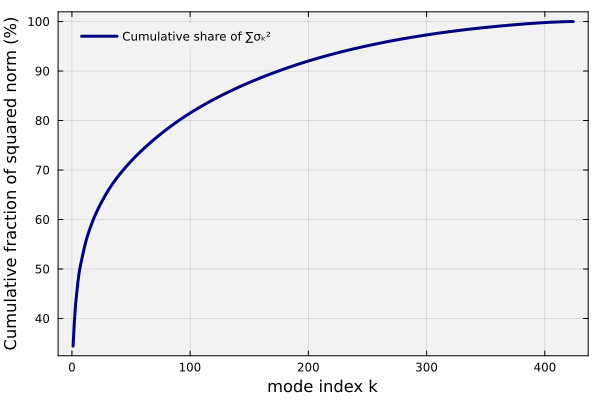

In [10]:
let
    
    # Compute the cumulative contribution of the singular modes -
    number_of_modes = length(S); # one mode for each singular value
    SS = S.^2/sum(S.^2); # fraction of the squared Frobenius norm
    explained_array = [100*sum(SS[1:k]) for k ∈ 1:number_of_modes]; # cumulative percentage through mode k

    # Display the cumulative modal contribution -
    plot(explained_array, label="Cumulative share of ∑σₖ²", lw=3, c=:navy)
    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
    xlabel!("mode index k", fontsize=18)
    ylabel!("Cumulative fraction of squared norm (%)", fontsize=18)
end

### What do the singular values tell us about the market behavior?

The plot above shows how the cumulative fraction of squared variation grows as we add modes. The shape of that curve tells us how concentrated the market's movement is.

> **Key Insight**: The first mode alone carries roughly a third of the total squared variation, and about 7 modes (fewer than 2% of them) reach 50%. That points to a single market-wide factor moving the component stocks together. The rest has a long tail: roughly 175 modes are needed to reach 90%. That tail is what we would expect from industry groups, individual company performance, and one-off events layered on top of the shared market move.

The singular values tell us how much each mode contributes. Next, the right singular vectors tell us which firms and sectors define those modes.


### Which Sectors Define the Leading Modes?

Mode $k$ has a right singular vector $\mathbf{v}_{k}$, which is column $k$ of $\mathbf{V}$. That vector holds one number per firm. The number for firm $j$ is the __loading__ $V_{jk}$. It says how much firm $j$ takes part in mode $k$. If we group the loadings by sector, we can see which part of the market each mode describes.

Every firm needs a sector label. We take the labels from a bundled Global Industry Classification Standard (GICS) snapshot and join them to our list of firms. The snapshot and the price dataset cover different firms, so some firms get no label. We print how many firms matched instead of assuming they all did. We then average the loadings of the matched firms in each sector.

The sign of a mode is arbitrary. Only the pair $\mathbf{u}_{k}$ and $\mathbf{v}_{k}$ is pinned down, because flipping the sign of both leaves the reconstruction unchanged. For the figure we copy each $\mathbf{v}_{k}$ and flip the whole copy when its largest-magnitude loading is negative. That way the code draws the same picture every time we run it.

So what can we read from a loading? Two things. The magnitude $|V_{jk}|$ says how strongly firm $j$ takes part in mode $k$. The sign says which way firm $j$ moves compared to the other firms in the same mode. Two firms with the same sign move together. Two firms with opposite signs move opposite ways. One loading's sign on its own tells us nothing, because flipping a mode flips every sign in it at once.

A positive loading is not a positive return. On day $i$, mode $k$ adds $\sigma_{k}U_{ik}V_{jk}$ to the growth rate of firm $j$. The loading $V_{jk}$ never changes, so the sign on a given day comes from $U_{ik}$, and that flips from day to day.

> __Mode 1 is the market mode:__ Every firm has the same sign in mode 1, so all firms move the same way when that mode is active. A mode can only set one group of sectors against another when some of its loadings are positive and some are negative. Mode 1 has no sign split, so it can only tell us which sectors move more strongly with the market and which move less. Mode 2 is the first mode that splits the sectors into opposing groups.

The mode 1 sector means span 0.026 to 0.063, a narrow band above zero. One shared color scale for all three modes would wash those contrasts out. The figure below divides each mode by its largest absolute sector mean and prints the unscaled means in the cells.

Sector coverage: 377 of 424 firms matched to GICS labels.


Mode 1: 424 of 424 firms load positive, 377 of 377 among the matched firms.
Mode 2: 155 of 424 firms load positive, 128 of 377 among the matched firms.
Mode 3: 145 of 424 firms load positive, 123 of 377 among the matched firms.


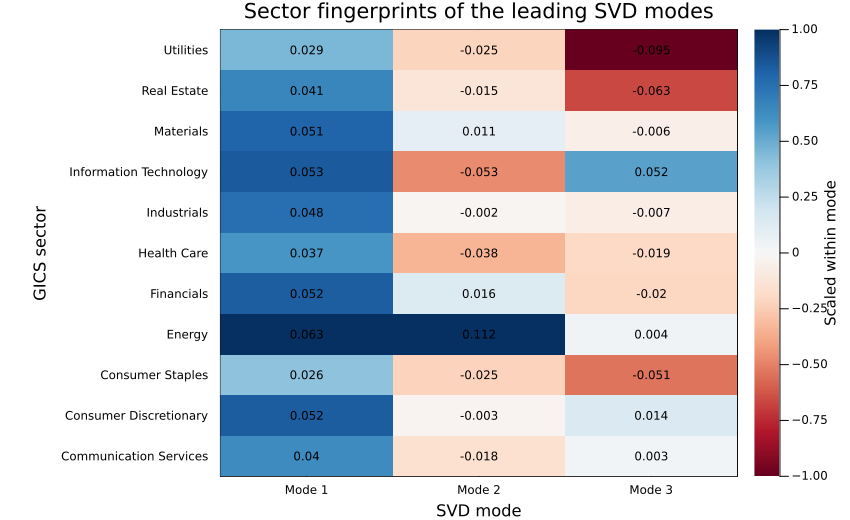

In [11]:
let

    # Initialize -
    number_of_modes_to_compare = 3; # leading firm-loading modes shown in the heatmap
    oriented_loadings = copy(V[:, 1:number_of_modes_to_compare]); # rows are firms; columns are SVD modes

    # Orient each mode by the sign of its largest absolute firm loading.
    for mode_index in axes(oriented_loadings, 2)
        anchor_index = argmax(abs.(oriented_loadings[:, mode_index])); # firm with the largest absolute loading
        if oriented_loadings[anchor_index, mode_index] < 0
            oriented_loadings[:, mode_index] .*= -1; # remove the arbitrary SVD sign flip
        end
    end

    # Match firm loadings to the bundled GICS sector snapshot.
    loading_data = DataFrame(:Symbol => list_of_tickers); # preserve row-to-ticker alignment from G and V
    for mode_index in axes(oriented_loadings, 2)
        loading_data[!, Symbol("Mode $(mode_index)")] = oriented_loadings[:, mode_index]; # add one loading column
    end
    sector_data = select(MySP500SectorDataSet(), :Symbol, Symbol("GICS Sector"));
    matched_loadings = innerjoin(loading_data, sector_data; on=:Symbol); # discard firms without sector metadata
    println("Sector coverage: $(nrow(matched_loadings)) of $(nrow(loading_data)) firms matched to GICS labels.");

    # How one-sided is each mode? A mode with all loadings of one sign cannot group sectors.
    for mode_index in axes(oriented_loadings, 2)
        all_loadings = oriented_loadings[:, mode_index]; # loadings for every firm in the growth-rate matrix
        matched_firm_loadings = matched_loadings[!, Symbol("Mode $(mode_index)")]; # sector-matched subset
        println("Mode $(mode_index): $(count(>(0), all_loadings)) of $(length(all_loadings)) firms load positive, "*
                "$(count(>(0), matched_firm_loadings)) of $(length(matched_firm_loadings)) among the matched firms.");
    end

    # Average the aligned firm loadings within each sector.
    sector_loading_summary = combine(groupby(matched_loadings, Symbol("GICS Sector"))) do frame
        (; [Symbol("Mode $(mode_index)") => mean(frame[!, Symbol("Mode $(mode_index)")])
            for mode_index in axes(oriented_loadings, 2)]...)
    end;
    sort!(sector_loading_summary, Symbol("GICS Sector"));

    sector_names = sector_loading_summary[!, Symbol("GICS Sector")]; # heatmap row labels
    loading_matrix = Matrix(sector_loading_summary[:, Not(Symbol("GICS Sector"))]); # unscaled sector means

    # Scale each mode by its own largest absolute sector mean, so the contrasts
    # inside every mode stay visible on one picture.
    scaled_matrix = similar(loading_matrix); # preserve the dimensions and numeric element type
    for mode_index in axes(loading_matrix, 2)
        scaled_matrix[:, mode_index] = loading_matrix[:, mode_index] ./ maximum(abs, loading_matrix[:, mode_index]); # map each mode to [-1,1]
    end

    # Display the normalized sector fingerprints -
    plt = heatmap(
        1:number_of_modes_to_compare,
        sector_names,
        scaled_matrix;
        color=:RdBu,
        clims=(-1, 1),
        colorbar_title="Scaled within mode",
        xticks=(1:number_of_modes_to_compare, ["Mode $(k)" for k in 1:number_of_modes_to_compare]),
        xlabel="SVD mode",
        ylabel="GICS sector",
        title="Sector fingerprints of the leading SVD modes",
        background_color=:white,
        background_color_outside=:white,
        framestyle=:box,
        left_margin=10Plots.mm,
        size=(850, 520),
    )

    # Print the unscaled mean loading in each cell. A categorical y-axis puts the row
    # sector_index across [sector_index - 1, sector_index], so its center is sector_index - 0.5.
    for sector_index in axes(loading_matrix, 1), mode_index in axes(loading_matrix, 2)
        annotate!(plt, mode_index, sector_index - 0.5,
            text(string(round(loading_matrix[sector_index, mode_index], digits=3)), 8, :black));
    end

    plt # return the annotated plot from the let block
end

What do we observe? In mode 1, all 424 firms have a positive loading. That is the __market mode__: on any given day it pushes every firm the same way, and $U_{i1}$ says which way and how hard. So mode 1 does not group sectors. It ranks sectors by how strongly they move with the market, from Energy at 0.063 down to Consumer Staples at 0.026.

Modes 2 and 3 do split the market. In mode 2 the Energy average is 0.112, while Information Technology is -0.053 and Health Care is -0.038. Opposite signs mean opposite directions. So on a day when mode 2 is active, it pushes the Energy average one way. It pushes the Information Technology and Health Care averages the other way. Mode 3 works the same way, with Information Technology at 0.052 against Utilities at -0.095, Real Estate at -0.063, and Consumer Staples at -0.051.

The singular values tell us how big each mode is. Only the loadings tell us which sectors are in it.

Next, let's reconstruct the growth-rate matrix and see how these modes combine.
___

## Task 3: Visualize the contribution of each mode
In this task, we'll rebuild the growth-rate matrix from its leading modes and view the result as a grayscale image, then compare it against the same picture drawn from all of the data.

In the visualization below, we'll reconstruct and display the market behavior using up to a specified number of modes. This shows how we can build up approximations of the original data matrix using progressively more components.

> **Visualization Approach**: We're creating grayscale images from the SVD components where each rank-1 matrix $\mathbf{G}_k = \sigma_k \mathbf{u}_k \mathbf{v}_k^{\top}$ represents one "mode" of market behavior. By converting the numerical growth rate values to color intensities (dark = negative, gray = moderate positive, light = large positive), we can visually see patterns in both time (horizontal direction) and across different stocks (vertical direction).

We store the individual market modes as grayscale frames in the `image_frames_dictionary::Dict{Int64, Matrix{Gray{Float64}}}` dictionary variable, where the key is the mode index, and the values are the corresponding weighted rank-one mode matrices.

In [12]:
image_frames_dictionary = let

    # Initialize -
    image_frames_dictionary = Dict{Int64,Matrix{Gray{Float64}}}(); # map each mode index to its grayscale rank-one frame

    # Build one rank-one reconstruction frame per nonzero singular mode -
    R = rank(growth_rate_array); # number of linearly independent modes
    foreach(k -> image_frames_dictionary[k] = S[k]*⊗(U[:,k],V[:,k]), 1:R); # frame k equals σₖ*uₖ*vₖ'

    image_frames_dictionary; # return the mode-indexed frames
end;

`Unhide` the code cell below to see how we computed and then visualized the cumulative contribution of each market mode. We've visualized the transpose of the growth rate matrix, so that time is on the horizontal axis, and firms are on the vertical axis.
> __Colors__: Dark values (black) indicate negative growth rates, gray values indicate moderate positive growth rates (between 0% and 5%), and light values (white) indicate large positive growth rates (greater than 5% per year).

So, do we see any interesting patterns in the modes of market behavior?

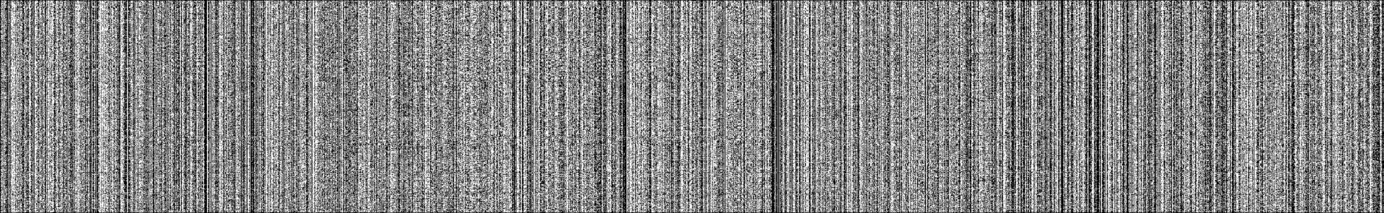

In [13]:
let 
    
    # Initialize the truncated reconstruction and display matrix -
    (number_of_trading_days, number_of_firms) = size(growth_rate_array); # row and column meanings of G
    B = zeros(number_of_trading_days, number_of_firms); # grayscale encoding with the same shape as G

    M = image_frames_dictionary[1]; # begin the truncated SVD reconstruction with mode 1
    number_of_frames = 100; # number of leading rank-one frames retained
    # Accumulate the remaining leading frames -
    for k ∈ 2:number_of_frames
        M += image_frames_dictionary[k] # add σₖ*uₖ*vₖ' to the reconstruction
    end

    # Encode reconstructed growth rates as dark, gray, or light pixels -
    for i ∈ 1:number_of_trading_days # i indexes trading-day steps
        for j ∈ 1:number_of_firms # j indexes firms
            if (M[i,j] < 0.0)
                B[i,j] = 0.0; # dark
            elseif (0.0 <= M[i,j] < 0.05)
                B[i,j] = 0.5; # gray
            else
                B[i,j] = 1.0; # light
            end
        end
    end

    Gray.(transpose(B)) # display firms as rows and trading-day steps as columns
end

`Unhide` the code cell below to see how we visualized the entire market behavior using all modes.
> __Colors__: Dark values (black) indicate negative growth rates, gray values indicate moderate positive growth rates (between 0% and 5%), and light values (white) indicate large positive growth rates (greater than 5% per year).

How does the entire market behavior look when we use all modes?

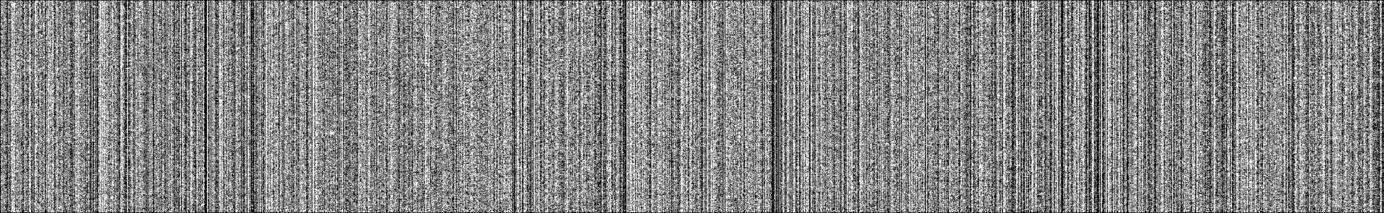

In [14]:
let

    # Initialize a grayscale encoding of the observed growth-rate matrix -
    (number_of_trading_days, number_of_firms) = size(growth_rate_array); # row and column meanings of G
    B = zeros(number_of_trading_days, number_of_firms); # grayscale values aligned with G

    # Encode observed growth rates as dark, gray, or light pixels -
    for i ∈ 1:number_of_trading_days # i indexes trading-day steps
        for j ∈ 1:number_of_firms # j indexes firms
            if (growth_rate_array[i,j] < 0.0)
                B[i,j] = 0.0; # dark
            elseif (0.0 < growth_rate_array[i,j] < 0.05)
                B[i,j] = 0.5; # gray
            else
                B[i,j] = 1.0; # light
            end
        end
    end

    Gray.(transpose(B)) # display firms as rows and trading-day steps as columns
end

### What patterns do we see in the market behavior?

Looking at the grayscale visualizations, we can observe several clear patterns in how the growth rates are distributed across time and firms.

> **Observable Patterns**: The visualizations show distinct vertical bands, with dark stripes on days when many firms had negative growth and light stripes during broad positive movement. Because the rows remain alphabetized by ticker, adjacency in this image does not identify economic groups. The sector-loading heatmap provides that evidence.

These visual patterns demonstrate that the SVD decomposition is successfully identifying structure in what might otherwise appear to be random market data. Pretty cool, right?
___

## Summary

This example applied singular value decomposition to a matrix of daily S&P 500 component growth rates and used low-rank reconstructions to expose shared market structure.

> __Key Takeaways:__
>
> * __The growth-rate matrix organizes two dimensions of variation:__ Rows represent trading-day intervals and columns represent firms, so the matrix records both temporal and cross-sectional behavior. That layout lets one factorization answer both when the market moved and which firms moved together.
> * __SVD orders orthogonal modes by importance:__ Each mode pairs one left and one right singular vector, and its singular value says how much of the variation in the data that mode carries. Because the modes are orthogonal, each one adds variation that the preceding modes do not already explain.
> * __Mode loadings expose shared structure:__ The leading mode spans sectors, later modes contrast sectors, and low-rank reconstructions separate shared patterns from increasingly asset-specific detail. A small number of modes therefore carries co-movement that a firm-by-firm view leaves implicit.

The decomposition shows that daily equity growth rates are not merely isolated firm-level observations: a comparatively small set of shared modes can organize a meaningful portion of their joint behavior.

___


## Disclaimer and Risks

__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products, and no investment or trading advice or strategy, is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing. Past performance, whether actual or indicated by historical tests, is no guarantee of future performance or success.

__You are fully responsible for any investment or trading decisions you make__. Distributional fits are approximations, Hill estimates are cutoff-sensitive, and the ACF reference bands shown above are pointwise large-sample diagnostics.